<a href="https://colab.research.google.com/github/seo104/26-2-ESAA/blob/main/%EB%AF%B8%EB%8B%88%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B81_%EC%8B%9C%EA%B0%81%ED%99%94(%EC%88%98%EC%A0%95%EB%B3%B8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##0. 준비

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/movies_train.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [3]:
#한글 폰트 설치
!apt-get -qq install fonts-nanum
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [5]:
#전처리

# 로그 스케일로 표현할 때 사용할 데이터
# 스태프 수가 0명인 영화는 로그 변환이 불가능하므로 제외
staff_positive_df = df[df['num_staff'] > 0].copy()

___
##4. 장르별 제작규모
###4-1 대규모 영화는 몇 명부터인가?
먼저 대규모의 기준을 정해야 한다.

대규모의 기준은 스태프 수의 75%(Q3)을 기준으로 상위 25%의 영화를 대규모 영화로 정의한다.

movies_train 데이터에서는 264명이 75%에 해당하므로 **스태프 수가 264명 이상인 영화를 대규모 영화로 정의한다.**

In [8]:
# 스태프 수의 75퍼센타일을 대규모 기준으로 설정
staff_threshold = df['num_staff'].quantile(0.75)

print(f'대규모 기준: 스태프 {staff_threshold:.0f}명 이상')

대규모 기준: 스태프 264명 이상


###4-2 장르별 대규모 영화의 비율

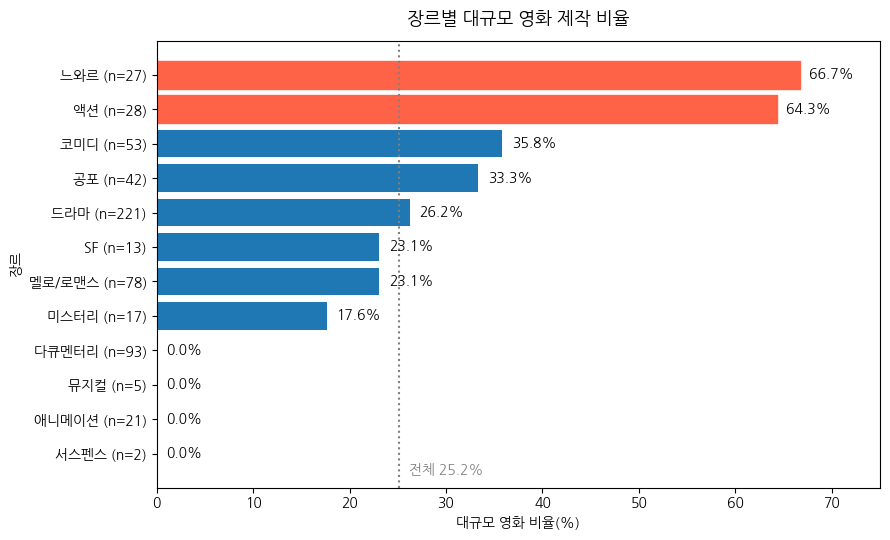

In [13]:
# 장르별 전체 영화 수와 대규모 영화 수를 계산
large_ratio = (
    df.groupby('genre')
      .agg(
          total=('genre', 'size'),
          large=('num_staff', lambda x: (x >= staff_threshold).sum())
      )
)

# 장르별 대규모 영화 비율 계산
large_ratio['ratio'] = large_ratio['large'] / large_ratio['total'] * 100

# 대규모 영화 비율이 높은 순으로 정렬
large_ratio = large_ratio.sort_values('ratio', ascending=False)

# 장르명에 전체 영화 수 표시
labels = [
    f'{genre} (n={total})'
    for genre, total in zip(large_ratio.index, large_ratio['total'])
]

# 그래프 작성
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(labels, large_ratio['ratio'])
ax.invert_yaxis()

# 대규모 영화 비율이 높은 상위 2개 장르 강조
for bar in bars[:2]:
    bar.set_color('tomato')

# 비율 표시
for bar, value in zip(bars, large_ratio['ratio']):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontsize=10
    )

# 전체 영화에서 대규모 영화가 차지하는 비율을 기준선으로 표시
overall_ratio = (df['num_staff'] >= staff_threshold).mean() * 100

ax.axvline(
    overall_ratio,
    linestyle=':',
    color='gray'
)

# 기준선 설명
ax.text(
    overall_ratio + 1,
    len(large_ratio) - 0.5,
    f'전체 {overall_ratio:.1f}%',
    va='center',
    fontsize=10,
    color='gray'
)

ax.set_title('장르별 대규모 영화 제작 비율', fontsize=13, pad=12)
ax.set_xlabel('대규모 영화 비율(%)')
ax.set_ylabel('장르')
ax.set_xlim(0, 75)

plt.tight_layout()
plt.show()

장르별 대규모 영화의 비율을 비교한 결과, 장르에 따라 대규모 영화가 차지하는 비중에 차이가 나타났다. 그래프의 점선은 전체 영화에서 대규모 영화가 차지하는 비율을 나타내며, 이를 기준으로 각 장르의 대규모 영화 비율이 전체 수준보다 높은지 낮은지를 비교할 수 있다. 특히 일부 장르는 대규모 영화의 비율이 높은 반면, 다른 장르는 상대적으로 낮은 비율을 보였다. 다만 비율이 0.0%인 장르도 전체 영화 수에 따라 해석에 차이가 있다. 예를 들어 다큐멘터리는 93편 중 대규모 영화가 없지만, 서스펜스는 2편 중 대규모 영화가 없어 동일한 0.0%라도 표본 수를 함께 고려해야 한다.

이는 장르에 따라 스태프 수의 규모가 다르다는 것을 보여준다. 다만 이 규모 차이가 관객수로 이어지는지는 이 그래프만으로는 알 수 없다. 그렇다면 대규모 영화로 제작되는 비중이 장르마다 다른 것에서 나아가, 대규모 영화 안에서도 장르에 따라 흥행 결과에 차이가 나타날까?
이를 확인하기 위해 대규모 영화만을 대상으로 장르별 관객수의 하한선을 비교하고, 각 장르에서 대규모 제작을 했을 때 낮은 관객수로 끝나는 영화가 얼마나 나타나는지 살펴보자.
###4-3 대규모 영화에서 장르별 흥행 하한선
데이터 파일에서 전체 관객수는 평균과 중앙값의 차이가 매우 크고, 소수의 대흥행작 때문에 평균이 크게 올라가는 분포이다. 따라서, 중앙값으로 장르별 관객 수를 비교하면 각 장르에서 일반적으로 어느 정도의 관객수를 기록하는지 확인할 수 있다. 하지만, 낮은 관객수를 기록한 영화가 얼마나 자주 나타나는지는 알기 어렵기 때문에 100만 관객 미만 영화의 비율로 장르별 흥행 하한선을 비교해보자.

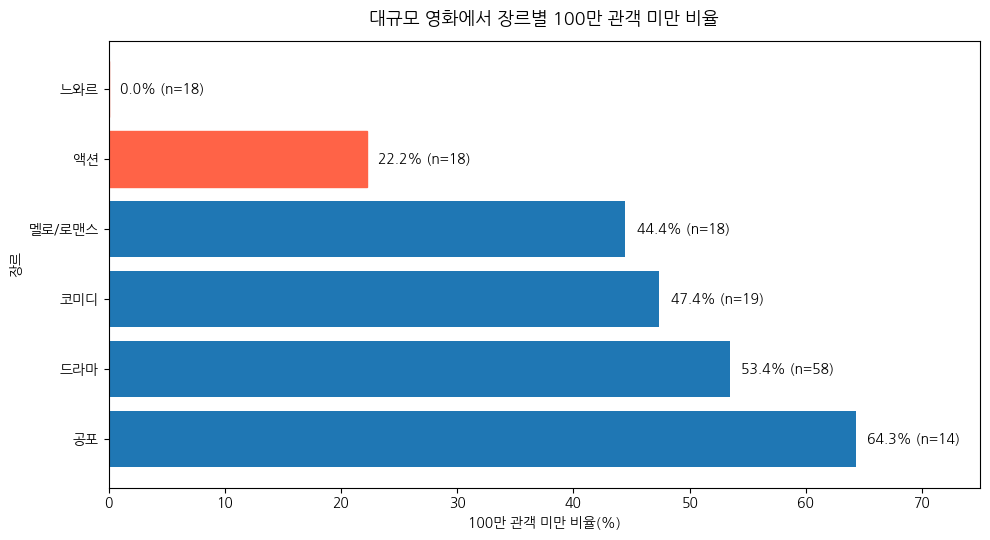

In [17]:
# 대규모 영화만 추출
large_df = df[df['num_staff'] >= staff_threshold]

# 장르별 대규모 영화 수와 100만 관객 미만 비율 계산
large_stats = (
    large_df.groupby('genre')
    .agg(
        count=('box_off_num', 'size'),
        under_1m=(
            'box_off_num',
            lambda x: (x < 1_000_000).mean() * 100
        )
    )
)

# 표본이 너무 적은 장르는 제외
large_stats = large_stats[large_stats['count'] >= 5]

# 100만 관객 미만 비율이 낮은 순으로 정렬
large_stats = large_stats.sort_values('under_1m')

large_stats

# 장르별 100만 관객 미만 비율을 막대그래프로 표현
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    large_stats.index,
    large_stats['under_1m']
)

# 비율이 낮은 상위 2개 장르 강조
for bar in bars[:2]:
    bar.set_color('tomato')

ax.invert_yaxis()

# 각 막대에 비율과 영화 수 표시
for bar, value, count in zip(
    bars,
    large_stats['under_1m'],
    large_stats['count']
):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}% (n={count})',
        va='center',
        fontsize=10
    )

ax.set_title(
    '대규모 영화에서 장르별 100만 관객 미만 비율',
    fontsize=13,
    pad=12
)
ax.set_xlabel('100만 관객 미만 비율(%)')
ax.set_ylabel('장르')
ax.set_xlim(0, 75)

plt.tight_layout()
plt.show()

대규모 영화에서 느와르는 100만 관객 미만인 영화가 나타나지 않은 반면, 공포는 100만 관객 미만인 영화의 비율이 가장 높게 나타났다. 이를 통해 대규모 영화에서도 장르에 따라 흥행 결과에 차이가 나타나는 것을 확인할 수 있다.

종합하면, 장르에 따라 대규모로 제작되는 영화의 비율에 차이가 나타났으며, 대규모 영화만을 대상으로 비교했을 때에도 장르에 따라 흥행 결과에 차이가 나타났다. 즉, 제작 규모가 크다고 해서 모든 장르에서 비슷한 수준의 흥행 결과가 나타나는 것은 아니었으며, 대규모 영화에서도 장르에 따른 차이를 확인할 수 있었다. 따라서 영화의 흥행 성적을 살펴볼 때 제작 규모뿐만 아니라 장르도 함께 고려할 필요가 있다.

___
##10. 상영시간X스태프 수의 관계
상영시간과 스태프 수의 관계가 단순한 직선 형태라고 가정하기에는 어려움이 있다. 따라서, 비선형적인 관계의 전체적인 흐름을 확인하기 위해 LOWESS 곡선을 이용해 나타낸다.

In [18]:
# 스태프 수가 0명인 작품 수 확인
zero_staff_count = (df['num_staff'] == 0).sum()

print(f'스태프 0명인 작품 수: {zero_staff_count}편')

스태프 0명인 작품 수: 32편


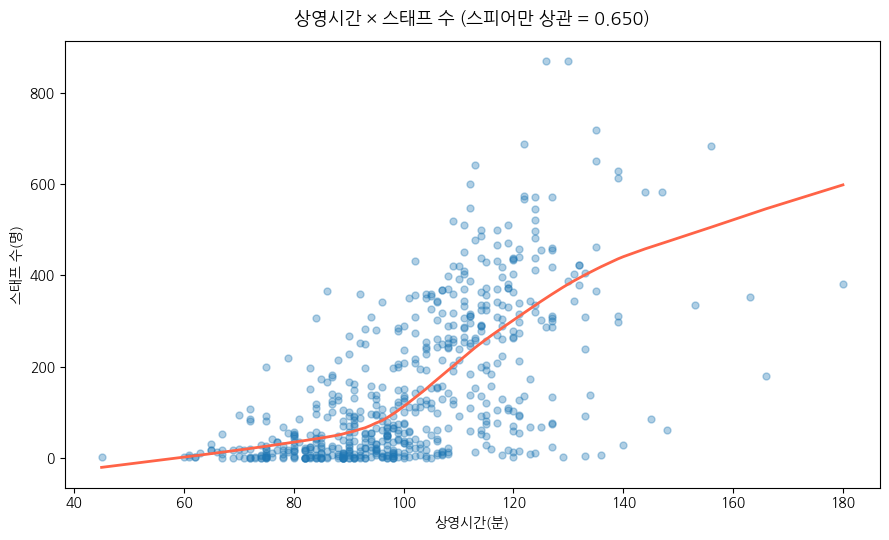

In [20]:
# 전체 작품을 대상으로 스피어만 상관계수 계산
spearman = df[['time', 'num_staff']].corr(method='spearman').iloc[0, 1]

# 산점도와 LOWESS 곡선으로 관계 확인
plt.figure(figsize=(9, 5.5))

sns.regplot(
    data=df,
    x='time',
    y='num_staff',
    lowess=True,
    scatter_kws={'alpha': 0.35, 's': 25},
    line_kws={'color': 'tomato', 'linewidth': 2}
)

plt.title(
    '상영시간 × 스태프 수 (스피어만 상관 = %.3f)' % spearman,
    fontsize=13,
    pad=12
)
plt.xlabel('상영시간(분)')
plt.ylabel('스태프 수(명)')

plt.tight_layout()
plt.show()

LOWESS 곡선을 확인한 결과, 상영시간이 증가할수록 스태프 수도 증가하는 경향이 나타났다. 특히 100분 전후부터 스태프 수가 크게 증가하고, 120분 이후에는 증가세가 다소 완만해지는 모습이 나타났다.

상영시간이 길어질수록 스태프 수가 증가하는 경향이 나타났지만, 이러한 증가가 모든 구간에서 동일하게 나타나는 것은 아니었다. 특히 일정 상영시간 구간에서는 스태프 수가 크게 증가한 반면, 그 이후에는 상영시간이 더 길어져도 스태프 수의 증가세가 둔화되는 모습을 보였다. 이는 영화의 상영시간이 길어지는 것만으로 제작에 필요한 스태프 규모가 계속해서 비례적으로 증가한다고 보기는 어렵다는 점을 보여준다. 따라서 영화 제작에서 스태프 규모는 상영시간과 관련이 있지만, 일정 수준 이상의 상영시간에서는 다른 요인들도 함께 고려할 필요가 있음을 시사한다.